# 오버샘플링

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# 데이터 로드
data_path = '/content/drive/MyDrive/newfile.csv'
Machine_fail = pd.read_csv(data_path)

# 데이터 자료형에 따른 column 구분
y_column = ['Machine failure']
numeric_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# na값 제거
Machine_fail_cleaned = Machine_fail.dropna()

# 카테고리형 변수 인코딩
Machine_fail_encoded = pd.get_dummies(Machine_fail_cleaned[y_column], drop_first=True)

Machine_fail_combined = pd.concat([Machine_fail_encoded, Machine_fail_cleaned[numeric_columns]], axis=1)

# 추출할 특징
y_column = ['Machine failure']
ext_ordinal_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# 추출된 특징만을 포함할 데이터
ext_Machine_fail_combined = Machine_fail_combined[y_column + ext_ordinal_columns]

# 학습 및 평가 데이터 분리
X = ext_Machine_fail_combined.drop(y_column, axis=1)
y = ext_Machine_fail_combined[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Mounted at /content/drive


In [2]:
from imblearn.over_sampling import SMOTE

# SMOTE를 이용한 오버샘플링
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 오버샘플링 후 클래스 별 데이터 수 확인
print("Resampled minority class count:", len(y_train_resampled[y_train_resampled == 1]))
print("Resampled majority class count:", len(y_train_resampled[y_train_resampled == 0]))

Resampled minority class count: 214866
Resampled majority class count: 214866


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# SVC 모델 생성
svm = SVC()

# 탐색할 파라미터 그리드 생성
param_grid = {
    'C': [0.1, 1, 10],
}

# 그리드 탐색을 위한 객체 생성
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=3, scoring='accuracy')

# 그리드 탐색 수행
grid_search.fit(X_train_resampled, y_train_resampled)

# 최적의 파라미터 출력
print("Best parameters:", grid_search.best_params_)

In [3]:
from sklearn.svm import SVC

# 클래스에 대한 사용자 정의 가중치 설정
class_weights = {0: 1, 1: 1}
svm = SVC(kernel='rbf', C=10, class_weight=class_weights)

In [4]:
svm.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=10, class_weight={0: 1, 1: 1})

In [5]:
# 예측 수행
y_train_pred_svm = svm.predict(X_train_resampled)
y_test_pred_svm = svm.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train_resampled, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

print(f'학습 데이터를 이용한 SVM Acc 값 : {acc_train*100:.1f}%')
print(f'평가 데이터를 이용한 SVM Acc 값 : {acc_test*100:.1f}%')

# 평가 지표 계산: 정밀도, 재현율, F1 점수
precision_test = precision_score(y_test, y_test_pred_svm)
recall_test = recall_score(y_test, y_test_pred_svm)
f1_test = f1_score(y_test, y_test_pred_svm)
print(f'SVM의 Precision : {precision_test:.2f}')
print(f'SVM의 Recall : {recall_test:.2f}')
print(f'SVM의 F1 score : {f1_test:.2f}')

학습 데이터를 이용한 SVM Acc 값 : 77.4%
평가 데이터를 이용한 SVM Acc 값 : 83.7%
SVM의 Precision : 0.07
SVM의 Recall : 0.71
SVM의 F1 score : 0.12


In [7]:
from sklearn.metrics import roc_auc_score

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train_resampled, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

# 평가 지표 계산: 정밀도, 재현율, F1 점수
precision_test = precision_score(y_test, y_test_pred_svm)
recall_test = recall_score(y_test, y_test_pred_svm)
f1_test = f1_score(y_test, y_test_pred_svm)

# AUC Score 계산
auc_score = roc_auc_score(y_test, y_test_pred_svm)

print(f'Accuracy: {acc_test}')
print(f'AUC Score: {auc_score}')
print(f'Precision: {precision_test}')
print(f'Recall: {recall_test}')
print(f'F1 Score: {f1_test}')

Accuracy: 0.8370226489774976
AUC Score: 0.774569910907201
Precision: 0.06715612178795077
Recall: 0.7100456621004566
F1 Score: 0.12270664825409353


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_test_pred_svm)
report = classification_report(y_test, y_test_pred_svm)
conf_matrix = confusion_matrix(y_test,y_test_pred_svm)

print(conf_matrix)
print(report)

[[22528  4320]
 [  127   311]]
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     26848
           1       0.07      0.71      0.12       438

    accuracy                           0.84     27286
   macro avg       0.53      0.77      0.52     27286
weighted avg       0.98      0.84      0.90     27286



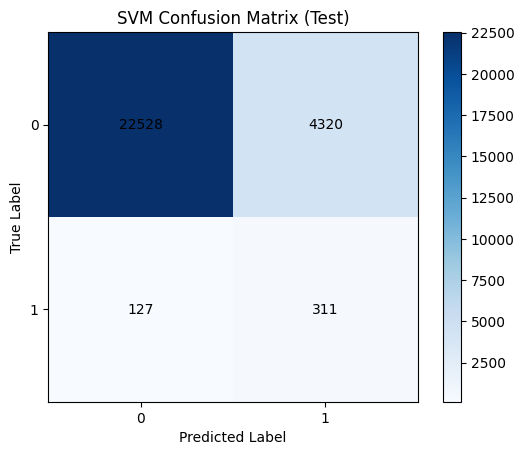

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix을 활용한 평가 결과 확인
cm_test_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")

In [17]:
# threshold를 0.7로 설정하여 계산
new_threshold = 0.7
y_pred_new_threshold = (y_scores >= new_threshold).astype(int)

# 새로운 threshold로 계산
acc_test = accuracy_score(y_test, y_pred_new_threshold)
auc_score = roc_auc_score(y_test, y_pred_new_threshold)
precision_new_threshold = precision_score(y_test, y_pred_new_threshold)
recall_new_threshold = recall_score(y_test, y_pred_new_threshold)
f1_score_new_threshold = f1_score(y_test, y_pred_new_threshold)
conf_matrix_new_threshold = confusion_matrix(y_test,y_pred_new_threshold)

print(f'Accuracy: {acc_test}')
print(f'AUC Score: {auc_score}')
print("Precision:", precision_new_threshold)
print("Recall:", recall_new_threshold)
print("f1 Score:", f1_score_new_threshold)
print(conf_matrix_new_threshold)

Accuracy: 0.9364875760463242
AUC Score: 0.7577379640363338
Precision: 0.13967723984418476
Recall: 0.5730593607305936
f1 Score: 0.22460850111856825
[[25302  1546]
 [  187   251]]


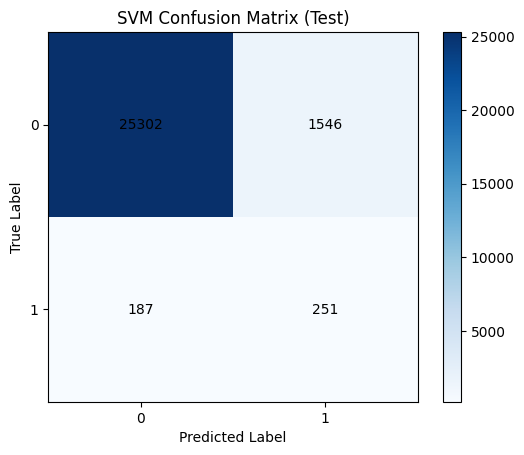

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix을 활용한 평가 결과 확인
cm_test_svm = confusion_matrix(y_test, y_pred_new_threshold)

plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")

# 언더샘플링

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# 데이터 로드
data_path = '/content/drive/MyDrive/newfile.csv'
Machine_fail = pd.read_csv(data_path)

# 데이터 자료형에 따른 column 구분
y_column = ['Machine failure']
numeric_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# na값 제거
Machine_fail_cleaned = Machine_fail.dropna()

# 카테고리형 변수 인코딩
Machine_fail_encoded = pd.get_dummies(Machine_fail_cleaned[y_column], drop_first=True)

Machine_fail_combined = pd.concat([Machine_fail_encoded, Machine_fail_cleaned[numeric_columns]], axis=1)

# 추출할 특징
y_column = ['Machine failure']
ext_ordinal_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Power','RotationalSpeed_TorqueRatio','ToolWearRate','Temperature_Difference']

# 추출된 특징만을 포함할 데이터
ext_Machine_fail_combined = Machine_fail_combined[y_column + ext_ordinal_columns]

# 학습 및 평가 데이터 분리
X = ext_Machine_fail_combined.drop(y_column, axis=1)
y = ext_Machine_fail_combined[y_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
from imblearn.under_sampling import RandomUnderSampler

# 언더샘플링을 위한 객체 생성
undersampler = RandomUnderSampler(random_state=42)

# 언더샘플링 수행
X_train_resampled_under, y_train_resampled_under = undersampler.fit_resample(X_train, y_train)

# 언더샘플링 후 클래스 별 데이터 수 확인
print("Resampled minority class count:", len(y_train_resampled_under[y_train_resampled_under == 1]))
print("Resampled majority class count:", len(y_train_resampled_under[y_train_resampled_under == 0]))

Resampled minority class count: 3420
Resampled majority class count: 3420


In [21]:
from sklearn.svm import SVC

# 클래스에 대한 사용자 정의 가중치 설정
class_weights = {0: 1, 1: 1}
svm = SVC(kernel='rbf', C=10, class_weight=class_weights)

In [22]:
svm.fit(X_train_resampled_under, y_train_resampled_under)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=10, class_weight={0: 1, 1: 1})

In [23]:
# 예측 수행
y_train_pred_svm = svm.predict(X_train_resampled_under)
y_test_pred_svm = svm.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train_resampled_under, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

print(f'학습 데이터를 이용한 SVM Acc 값 : {acc_train*100:.1f}%')
print(f'평가 데이터를 이용한 SVM Acc 값 : {acc_test*100:.1f}%')

# 평가 지표 계산: 정밀도, 재현율, F1 점수
precision_test = precision_score(y_test, y_test_pred_svm)
recall_test = recall_score(y_test, y_test_pred_svm)
f1_test = f1_score(y_test, y_test_pred_svm)

print(f'SVM의 Precision : {precision_test:.2f}')
print(f'SVM의 Recall : {recall_test:.2f}')
print(f'SVM의 F1 score : {f1_test:.2f}')

학습 데이터를 이용한 SVM Acc 값 : 74.3%
평가 데이터를 이용한 SVM Acc 값 : 82.2%
SVM의 Precision : 0.06
SVM의 Recall : 0.67
SVM의 F1 score : 0.11


In [25]:
from sklearn.metrics import roc_auc_score

# 평가 지표 계산: 정확도 (맞은수/전체)
acc_train = accuracy_score(y_train_resampled_under, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

# 평가 지표 계산: 정밀도, 재현율, F1 점수
precision_test = precision_score(y_test, y_test_pred_svm)
recall_test = recall_score(y_test, y_test_pred_svm)
f1_test = f1_score(y_test, y_test_pred_svm)

# AUC Score 계산
auc_score = roc_auc_score(y_test, y_test_pred_svm)

print(f'Accuracy: {acc_test}')
print(f'AUC Score: {auc_score}')
print(f'Precision: {precision_test}')
print(f'Recall: {recall_test}')
print(f'F1 Score: {f1_test}')

Accuracy: 0.8218133841530455
AUC Score: 0.7477514204777377
Precision: 0.05865921787709497
Recall: 0.6712328767123288
F1 Score: 0.10788990825688073


In [26]:
from sklearn.metrics import classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_test_pred_svm)
report = classification_report(y_test, y_test_pred_svm)
conf_matrix = confusion_matrix(y_test,y_test_pred_svm)

print(conf_matrix)
print(report)

[[22130  4718]
 [  144   294]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90     26848
           1       0.06      0.67      0.11       438

    accuracy                           0.82     27286
   macro avg       0.53      0.75      0.50     27286
weighted avg       0.98      0.82      0.89     27286



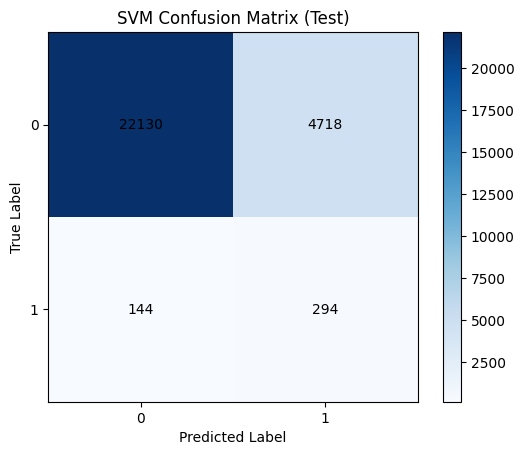

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix을 활용한 평가 결과 확인
cm_test_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")

In [28]:
# threshold를 0.7로 설정하여 계산
new_threshold = 0.7
y_pred_new_threshold = (y_scores >= new_threshold).astype(int)

# 새로운 threshold로 계산
acc_test = accuracy_score(y_test, y_pred_new_threshold)
auc_score = roc_auc_score(y_test, y_pred_new_threshold)
precision_new_threshold = precision_score(y_test, y_pred_new_threshold)
recall_new_threshold = recall_score(y_test, y_pred_new_threshold)
f1_score_new_threshold = f1_score(y_test, y_pred_new_threshold)
conf_matrix_new_threshold = confusion_matrix(y_test,y_pred_new_threshold)

print(f'Accuracy: {acc_test}')
print(f'AUC Score: {auc_score}')
print("Precision:", precision_new_threshold)
print("Recall:", recall_new_threshold)
print("f1 Score:", f1_score_new_threshold)
print(conf_matrix_new_threshold)

Accuracy: 0.9364875760463242
AUC Score: 0.7577379640363338
Precision: 0.13967723984418476
Recall: 0.5730593607305936
f1 Score: 0.22460850111856825
[[25302  1546]
 [  187   251]]


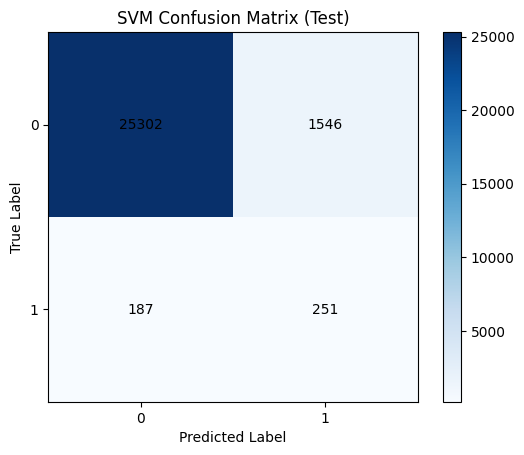

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# confusion matrix을 활용한 평가 결과 확인
cm_test_svm = confusion_matrix(y_test, y_pred_new_threshold)

plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 각 셀에 숫자 표시
for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")